In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [ ]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# Baseline period for Impact
BASELINE_PERIOD = slice("1996-01-01", "2025-12-31")
# Define Forecast Months
FC_MONTHS = [6, 7, 8, 9]

config = analysis_utils.ImpactConfig( version = "v261007",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=False, 
                                     months = FC_MONTHS,
                                     hotonly = "hotonly", 
                                     dims = ['sample'])


# Define Forecast
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/v261002_effects_hotonly_g100.zarr"
EFFECTS_URI_RT = "/home/emily_zuetell/projects/poreallas/data/2609_effects_running_total_tas.zarr"

In [3]:
# Projection Effects
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
effect_rt = xr.open_datatree(EFFECTS_URI_RT, consolidated=False)

In [4]:
effect['/forecast_hotonly'] = effect_rt['/forecast_hotonly_runningtotal']

In [5]:
### Log baseline period and impact calculation
rate_l = "rate" if config.rate else "total"
baseline_tag = analysis_utils._baseline_tag(config.baseline_period)

In [6]:
# Compute impact: forecast - baseline
impact = analysis_utils.compute_impact(
    effect.chunk({dim: -1 for dim in config.dims}),
    config,
    ensemble=True,
)
# Use only the defined 6-months
impact = impact.sel(month=config.months)

In [17]:
_polygons_impact = analysis_utils.xarray_to_gpd(
    impact.mean(dim="sample"), config.polygons
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [21]:
import plotting_utils

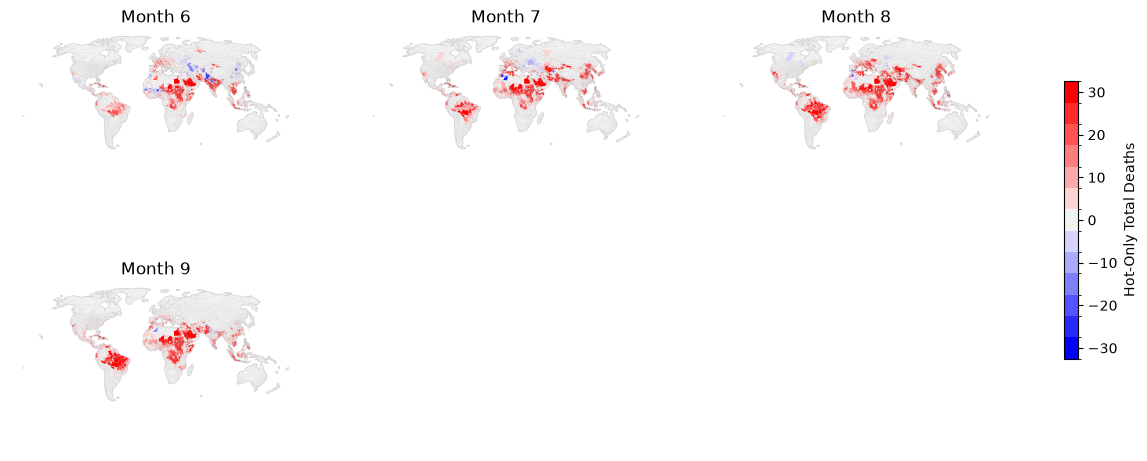

In [24]:
fig = plotting_utils.plot_monthly(
    _polygons_impact,
    col="age_weighted_impact",
    cm="bwr",
    n_colors=9,
    sup_title="",
    cbar_label="Hot-Only Total Deaths",
    month_order=[6, 7, 8, 9],
)

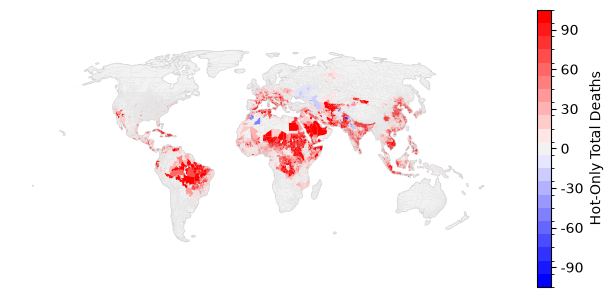

In [26]:
fig = plotting_utils.plot_aggregate(
    _polygons_impact,
    col="age_weighted_impact",
    agg = 'sum',
    cm="bwr",
    n_colors=13,
    sup_title="",
    cbar_label="Hot-Only Total Deaths",
)

In [10]:
impact.sel(month = [6, 7]).mean(dim = 'sample').sum(dim = ['region', 'month']).values

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


array(223819.42333695)

In [12]:
analysis_utils.make_csv(effect, config, group_level="IR")

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_